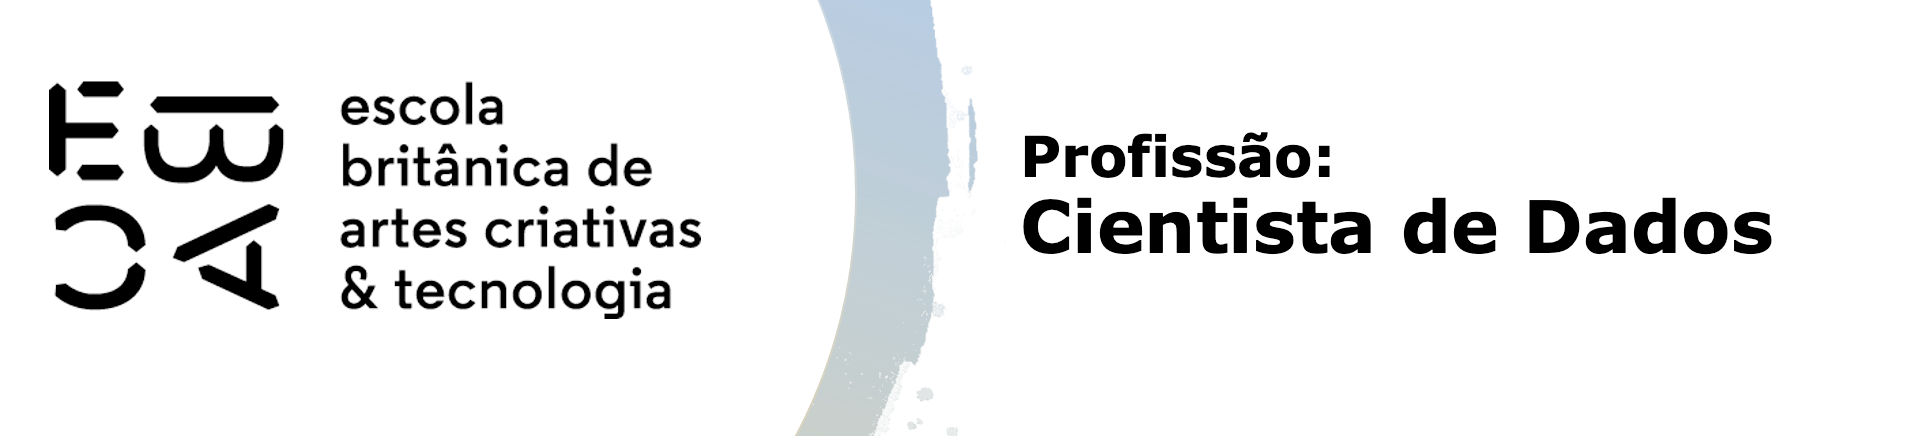

# Tarefa II

Ainda sobre a base da NFP vista na tarefa passada:

|Campo|Descrição|
|:-|:-|
|CNPJ emit.| CNPJ do emitente da nota|
|Emitente| Nome fantasia do emitente da nota|
|No.| Número da nota fiscal|
|Data Emissão| Data de emissão da nota fiscal|
|Valor NF| Valor da nota fiscal|
|Data Registro| Data de registro no sistema da NFP|
|Créditos| Valor dos créditos (doação)|
|Situação do Crédito| Se o crédito já foi pago, está sendo processado etc.|
|Ano| Ano da emissão da nota|
|Semestre| Semestre da emissão da nota|
|Retorno| Valor do crédito dividido pelo valor da nota|
|flag_credito| Indicadora se a nota possui crédito positivo|
|categoria| Categorização da nota |

**OBJETIVO:** Algumas notas não dão retorno, o que pode ocorrer por diversos motivos, um deles seria a ocorrência de produtos não incentivados como cigarros e bebidas alcólicas. O nosso objetivo é tentar prever que tipo de nota tem maior ou menor propensão a fornecer créditos.

**Observação**: Esta é uma base real, havendo características de acordo. Pode haver uma variabilidade difícil de explicar, em parte por causa de uma freqüência de notas inconstante no tempo (por diversos motivos), em parte por haverem informações importantes, protegidas pela LGPD, não constantes na base, que pode interferir no crédito gerado, o que vai ocasionar uma variabilidade difícil de se explicar. *Welcome to the jungle*, A vida real é assim :)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings;   
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_pickle('base_nfp.pkl')
df.set_index('Data Emissão', inplace=True)
df1 = df['2020-01-01':]
df1.reset_index(inplace=True)
print(df1.shape)
print(df1.info())
df1.head()

(86956, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86956 entries, 0 to 86955
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Data Emissão         86956 non-null  datetime64[ns]
 1   CNPJ emit.           86956 non-null  object        
 2   Emitente             86956 non-null  object        
 3   No.                  86956 non-null  int64         
 4   Valor NF             86956 non-null  float64       
 5   Data Registro        86956 non-null  datetime64[ns]
 6   Créditos             86956 non-null  float64       
 7   Situação do Crédito  86956 non-null  category      
 8   Ano                  86956 non-null  int64         
 9   Semestre             86956 non-null  int64         
 10  Retorno              86000 non-null  float64       
 11  flag_credito         86956 non-null  int64         
 12  categoria            86956 non-null  object        
dtypes: category(1), dat

,Data Emissão,CNPJ emit.,Emitente,No.,Valor NF,Data Registro,Créditos,Situação do Crédito,Ano,Semestre,Retorno,flag_credito,categoria
0,2020-01-01,05.234.750/0001-41,TX BURGER LTDA,77882,78.80,2020-08-01,0.0,A Calcular,2019,2,0.0,0,não definido
1,2020-01-01,47.508.411/1476-88,CIA BRASILEIRA DE DISTRIBUICAO,20087,22.71,2020-01-01,0.0,A Calcular,2019,2,0.0,0,Mercado
2,2020-01-01,09.060.964/0108-39,PIMENTA VERDE ALIMENTOS LTDA,82366,35.90,2020-08-01,0.0,A Calcular,2019,2,0.0,0,Alimentos
3,2020-01-01,61.412.110/0307-39,DROGARIA SAO PAULO S A,234178,21.77,2020-08-01,0.0,A Calcular,2019,2,0.0,0,Farmácia
4,2020-01-01,46.952.032/0001-98,PANIFICADORA E CONFEITARIA QUELUZ LTDA,3305,80.95,2020-08-01,0.0,A Calcular,2019,2,0.0,0,Restaurantes


## Criando variáveis

**Variáveis temporais**: É possível que haja alguma regra de liberação de créditos de acordo com o dia do mês, o dia da semana, fim de semana (sim ou não), ou até alterações temporais da regra. Vamos criar as seguintes variáveis para testar estas hipóteses:

- Dia da semana
- Dummy para fim de semana
- Dia do mês
- Mês (já na base)
- Trimestre
- Ano (já na base)

**Valor da nota**: Vamos criar também algumas variáveis para resumir o valor da nota, e posteriormente criar uma intuição sobre categorizações de variáveis contínuas.

- Crie categorizações da variável ```Valor NF```, por quantís, em 5, 10, 20 e 50 categorias.

In [7]:
# Variáveis temporais
df1['Dia_de_semana'] = df1['Data Emissão'].dt.day_name()
df1['Fim_de_semana'] = ((df1['Data Emissão'].dt.dayofweek) // 5 == 1).astype(float)
df1['Dia_mes'] = df1['Data Emissão'].dt.day
df1['Mes'] = df1['Data Emissão'].dt.month
df1['Trimestre'] = df1['Data Emissão'].dt.quarter
df1['Ano'] = df1['Data Emissão'].dt.year
df1.head()


,Data Emissão,CNPJ emit.,Emitente,No.,Valor NF,Data Registro,Créditos,Situação do Crédito,Ano,Semestre,Retorno,flag_credito,categoria,Dia_de_semana,Fim_de_semana,Dia_mes,Mes,Trimestre
0,2020-01-01,05.234.750/0001-41,TX BURGER LTDA,77882,78.80,2020-08-01,0.0,A Calcular,2020,2,0.0,0,não definido,Wednesday,0.0,1,1,1
1,2020-01-01,47.508.411/1476-88,CIA BRASILEIRA DE DISTRIBUICAO,20087,22.71,2020-01-01,0.0,A Calcular,2020,2,0.0,0,Mercado,Wednesday,0.0,1,1,1
2,2020-01-01,09.060.964/0108-39,PIMENTA VERDE ALIMENTOS LTDA,82366,35.90,2020-08-01,0.0,A Calcular,2020,2,0.0,0,Alimentos,Wednesday,0.0,1,1,1
3,2020-01-01,61.412.110/0307-39,DROGARIA SAO PAULO S A,234178,21.77,2020-08-01,0.0,A Calcular,2020,2,0.0,0,Farmácia,Wednesday,0.0,1,1,1
4,2020-01-01,46.952.032/0001-98,PANIFICADORA E CONFEITARIA QUELUZ LTDA,3305,80.95,2020-08-01,0.0,A Calcular,2020,2,0.0,0,Restaurantes,Wednesday,0.0,1,1,1


In [8]:
# Criando categorias por quantis:
df1['valor_nf_cat_5'] = pd.qcut(df1['Valor NF'], q=5, labels=False)  # 5 categorias
df1['valor_nf_cat_10'] = pd.qcut(df1['Valor NF'], q=10, labels=False)  # 10 categorias
df1['valor_nf_cat_20'] = pd.qcut(df1['Valor NF'], q=20, labels=False, duplicates='drop')  # 20 categorias
df1['valor_nf_cat_50'] = pd.qcut(df1['Valor NF'], q=50, labels=False, duplicates='drop')  # 50 categorias
# Exibindo o resultado:
df1.head()

,Data Emissão,CNPJ emit.,Emitente,No.,Valor NF,Data Registro,Créditos,Situação do Crédito,Ano,Semestre,...,categoria,Dia_de_semana,Fim_de_semana,Dia_mes,Mes,Trimestre,valor_nf_cat_5,valor_nf_cat_10,valor_nf_cat_20,valor_nf_cat_50
0,2020-01-01,05.234.750/0001-41,TX BURGER LTDA,77882,78.80,2020-08-01,0.0,A Calcular,2020,2,...,não definido,Wednesday,0.0,1,1,1,2,5,11,27
1,2020-01-01,47.508.411/1476-88,CIA BRASILEIRA DE DISTRIBUICAO,20087,22.71,2020-01-01,0.0,A Calcular,2020,2,...,Mercado,Wednesday,0.0,1,1,1,0,1,3,9
2,2020-01-01,09.060.964/0108-39,PIMENTA VERDE ALIMENTOS LTDA,82366,35.90,2020-08-01,0.0,A Calcular,2020,2,...,Alimentos,Wednesday,0.0,1,1,1,1,3,6,15
3,2020-01-01,61.412.110/0307-39,DROGARIA SAO PAULO S A,234178,21.77,2020-08-01,0.0,A Calcular,2020,2,...,Farmácia,Wednesday,0.0,1,1,1,0,1,3,8
4,2020-01-01,46.952.032/0001-98,PANIFICADORA E CONFEITARIA QUELUZ LTDA,3305,80.95,2020-08-01,0.0,A Calcular,2020,2,...,Restaurantes,Wednesday,0.0,1,1,1,2,5,11,28


## Calcule o IV de todas essas variáveis

Sugestão: Construa um metadados e tente utilizar uma função como a que foi utilizada durante a aula. Você vai conseguir fazer esse cálculo para as variáveis uma a uma, mas em casos reais em que vamos mais além na criação de variáveis, podemos ter centenas, ou até milhares de variáveis, esses cálculos *precisam* ser automáticos nesses casos.

In [10]:
#Definindo o metadados
df2 = df1.copy()
df2.drop(columns=['Data Emissão',
    'CNPJ emit.',
    'Emitente',
    'No.',
    'Valor NF',
    'Data Registro',
    'Créditos',
    'Situação do Crédito',
    'Retorno'], inplace=True)
metadados = pd.DataFrame({'dtype':df2.dtypes})
metadados

,dtype
Ano,int32
Semestre,int64
flag_credito,int64
categoria,object
Dia_de_semana,object
Fim_de_semana,float64
Dia_mes,int32
Mes,int32
Trimestre,int32
valor_nf_cat_5,int64


In [11]:
#Atribuindo papéis
metadados['papel'] = 'covariavel'
metadados.loc['flag_credito','papel'] = 'resposta'
metadados['nunique'] = df2.nunique()
metadados

,dtype,papel,nunique
Ano,int32,covariavel,2
Semestre,int64,covariavel,2
flag_credito,int64,resposta,2
categoria,object,covariavel,9
Dia_de_semana,object,covariavel,7
Fim_de_semana,float64,covariavel,2
Dia_mes,int32,covariavel,31
Mes,int32,covariavel,12
Trimestre,int32,covariavel,4
valor_nf_cat_5,int64,covariavel,5


In [12]:
# Função IV
def IV(variavel, resposta):
    tab = pd.crosstab(variavel, resposta, margins=True, margins_name='total')

    rótulo_evento = tab.columns[0]
    rótulo_nao_evento = tab.columns[1]

    tab['pct_evento'] = tab[rótulo_evento]/tab.loc['total',rótulo_evento]
    tab['pct_nao_evento'] = tab[rótulo_nao_evento]/tab.loc['total',rótulo_nao_evento]
    tab['woe'] = np.log(tab.pct_evento/tab.pct_nao_evento)
    tab['iv_parcial'] = (tab.pct_evento - tab.pct_nao_evento)*tab.woe
    return tab['iv_parcial'].sum()

# Populando o metadados
for var in metadados[metadados.papel == 'covariavel'].index:
    if pd.api.types.is_numeric_dtype(df2[var]):
        if metadados.loc[var, 'nunique'] > 50:
            metadados.loc[var, 'IV'] = IV(pd.qcut(df2[var], 5, duplicates='drop'), df2.flag_credito)
        else:
            metadados.loc[var, 'IV'] = IV(df2[var], df2.flag_credito)
    else:
        metadados.loc[var, 'IV'] = IV(df2[var], df2.flag_credito)

In [13]:
# Interpretação dos valores de IV
metadados.loc[metadados['IV'] < 0.02, 'poder_preditivo'] = 'Irrelevante'
metadados.loc[(metadados['IV'] >= 0.02) & (metadados['IV'] <= 0.1), 'poder_preditivo'] = 'Fraco'
metadados.loc[(metadados['IV'] > 0.1) & (metadados['IV'] <= 0.3), 'poder_preditivo'] = 'Médio'
metadados.loc[(metadados['IV'] > 0.3) & (metadados['IV'] <= 0.5), 'poder_preditivo'] = 'Forte'
metadados.loc[metadados['IV'] > 0.5, 'poder_preditivo'] = 'Atenção, muito alto'
metadados

,dtype,papel,nunique,IV,poder_preditivo
Ano,int32,covariavel,2,0.003195,Irrelevante
Semestre,int64,covariavel,2,0.004874,Irrelevante
flag_credito,int64,resposta,2,NaN,nan
categoria,object,covariavel,9,0.278826,Médio
Dia_de_semana,object,covariavel,7,0.005878,Irrelevante
Fim_de_semana,float64,covariavel,2,0.004599,Irrelevante
Dia_mes,int32,covariavel,31,0.015128,Irrelevante
Mes,int32,covariavel,12,0.009098,Irrelevante
Trimestre,int32,covariavel,4,0.003554,Irrelevante
valor_nf_cat_5,int64,covariavel,5,0.038990,Fraco


## Conclua

- Quais variáveis parecem apresentar maior poder de discriminação segundo o IV?
- Quando categorizamos variáveis contínuas parece haver alguma relação entre o número de categorias e o IV?

A variável categoria é a que possui maior poder discriminativo, com IV médio, consolidando-se como a variável mais relevante para modelos preditivos neste contexto.

A variável Valor NF, quando discretizada em um número maior de categorias (exemplo: 50 categorias), também demonstra poder preditivo médio, destacando a importância de uma boa segmentação das variáveis contínuas.

As demais variáveis analisadas apresentam poder preditivo fraco ou praticamente irrelevante.
  
Assim, podemos considerar que temos duas variáveis com poder significativo de discriminação para o modelo:  
1. Categoria – maior poder preditivo e discriminação média.  
2. Valor NF – poder preditivo crescente com o aumento da granularidade da categorização.

## Descritiva simples no tempo

Para compor a análise que virá a seguir, faça uma análise descritiva básica no tempo - utilize trimestre como agregação (ou uma média móvel por trimestre, como preferir) e avalie graficamente:

- A quantidade de notas registradas na base por período
- A quantidade de notas por categoria e por período
- A proporção de notas com crédito por categoria por período

In [17]:
# Quantidade de notas registradas na base por período
df3 = df2.groupby(['Trimestre', 'flag_credito']).size().unstack(fill_value=0)
df3['N'] = df3.sum(axis=1)
df3.head()
df3

flag_credito,0,1,N
Trimestre,,,
1,11521,9146,20667
2,12167,8231,20398
3,12618,9720,22338
4,13332,10221,23553


In [18]:
df3 = df3.reset_index()
df3.head()


flag_credito,Trimestre,0,1,N
0,1,11521,9146,20667
1,2,12167,8231,20398
2,3,12618,9720,22338
3,4,13332,10221,23553


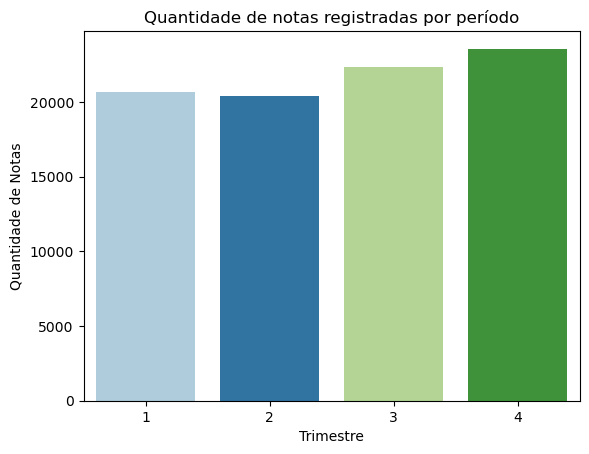

In [19]:
# Quantidade de notas registradas na base por período
sns.barplot(data=df3, x='Trimestre', y='N', palette='Paired')
plt.title('Quantidade de notas registradas por período')
plt.xlabel('Trimestre')
plt.ylabel('Quantidade de Notas')
plt.show()

In [20]:
# Quantidade de notas por categoria e por período
df4 = df2.groupby(['Trimestre', 'categoria', 'flag_credito']).size().unstack(fill_value=0)
df4['N'] = df4.sum(axis=1)
df4['tx_evento'] = df4[1] / df4['N']
df4.reset_index(inplace=True)
df4

flag_credito,Trimestre,categoria,0,1,N,tx_evento
0,1,Alimentos,374,908,1282,0.708268
1,1,Auto posto,118,34,152,0.223684
2,1,Construção,2043,1811,3854,0.469901
3,1,Farmácia,1794,638,2432,0.262336
4,1,Mercado,3456,3271,6727,0.486249
5,1,Restaurantes,164,590,754,0.782493
6,1,Varejo,777,172,949,0.181243
7,1,Vestuário,314,115,429,0.268065
8,1,não definido,2481,1607,4088,0.393102
9,2,Alimentos,431,736,1167,0.630677


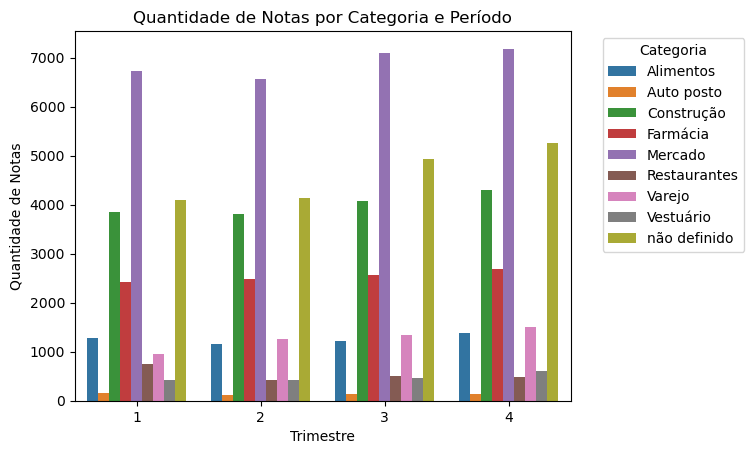

In [21]:
# Quantidade de notas por categoria e por período
sns.barplot(data=df4, x='Trimestre', y='N', hue='categoria')

plt.title('Quantidade de Notas por Categoria e Período')
plt.xlabel('Trimestre')
plt.ylabel('Quantidade de Notas')
plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

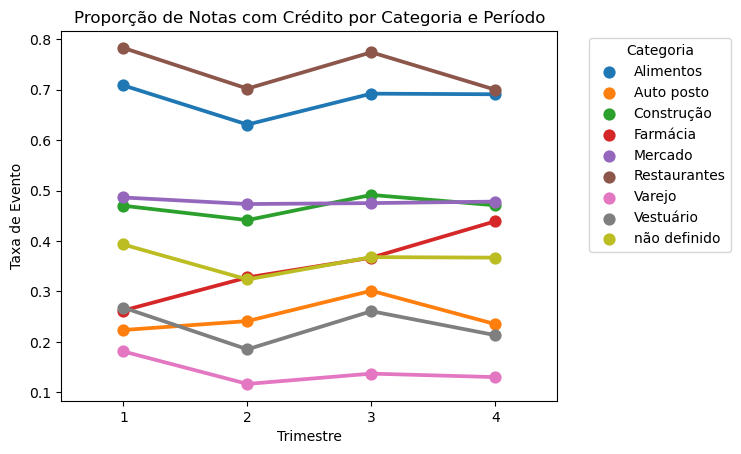

In [22]:

# Proporção de notas com crédito por categoria e período
sns.pointplot(data=df4, x='Trimestre', y='tx_evento', hue='categoria')
plt.title('Proporção de Notas com Crédito por Categoria e Período')
plt.xlabel('Trimestre')
plt.ylabel('Taxa de Evento')
plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Avalie o WOE e o IV no tempo

Avalie o WOE e o IV no tempo da variável ```categoria```.

In [24]:
df4 = df4.set_index('Trimestre')
df4

flag_credito,categoria,0,1,N,tx_evento
Trimestre,,,,,
1,Alimentos,374,908,1282,0.708268
1,Auto posto,118,34,152,0.223684
1,Construção,2043,1811,3854,0.469901
1,Farmácia,1794,638,2432,0.262336
1,Mercado,3456,3271,6727,0.486249
1,Restaurantes,164,590,754,0.782493
1,Varejo,777,172,949,0.181243
1,Vestuário,314,115,429,0.268065
1,não definido,2481,1607,4088,0.393102


In [25]:
rotulo_ev, rotulo_nev = (1, 0)
df4['pct_evento'] = df4[rotulo_ev]/df4[rotulo_ev].groupby(level=0).sum()
df4['pct_nao_evento'] = df4[rotulo_nev]/df4[rotulo_nev].groupby(level=0).sum()
df4['WOE'] = np.log(df4.pct_evento/df4.pct_nao_evento)
df4['IV'] = ((df4.pct_evento - df4.pct_nao_evento)*df4.WOE)
df4.loc[df4['IV'] < 0.02, 'poder_preditivo'] = 'Irrelevante'
df4.loc[(df4['IV'] >= 0.02) & (df4['IV'] <= 0.1), 'poder_preditivo'] = 'Fraco'
df4.loc[(df4['IV'] > 0.1) & (df4['IV'] <= 0.3), 'poder_preditivo'] = 'Médio'
df4.loc[(df4['IV'] > 0.3) & (df4['IV'] <= 0.5), 'poder_preditivo'] = 'Forte'
df4.loc[df4['IV'] > 0.5, 'poder_preditivo'] = 'Atenção, muito alto'
df4

flag_credito,categoria,0,1,N,tx_evento,pct_evento,pct_nao_evento,WOE,IV,poder_preditivo
Trimestre,,,,,,,,,,
1,Alimentos,374,908,1282,0.708268,0.099278,0.032462,1.117843,0.074690,Fraco
1,Auto posto,118,34,152,0.223684,0.003717,0.010242,-1.013469,0.006613,Irrelevante
1,Construção,2043,1811,3854,0.469901,0.198010,0.177328,0.110315,0.002281,Irrelevante
1,Farmácia,1794,638,2432,0.262336,0.069757,0.155716,-0.803010,0.069025,Fraco
1,Mercado,3456,3271,6727,0.486249,0.357643,0.299974,0.175839,0.010140,Irrelevante
1,Restaurantes,164,590,754,0.782493,0.064509,0.014235,1.511111,0.075970,Fraco
1,Varejo,777,172,949,0.181243,0.018806,0.067442,-1.277091,0.062113,Fraco
1,Vestuário,314,115,429,0.268065,0.012574,0.027255,-0.773606,0.011357,Irrelevante
1,não definido,2481,1607,4088,0.393102,0.175705,0.215346,-0.203438,0.008064,Irrelevante


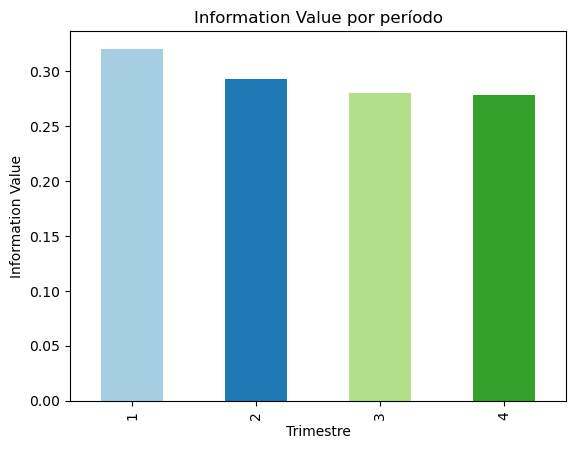

In [26]:
iv_categoria = ((df4.pct_evento - df4.pct_nao_evento)*df4.WOE).groupby(level=0).sum();
palette = sns.color_palette("Paired", len(iv_categoria))

iv_categoria.plot.bar(color=palette)
plt.title('Information Value por período')
plt.xlabel('Trimestre')
plt.ylabel('Information Value')
plt.show()

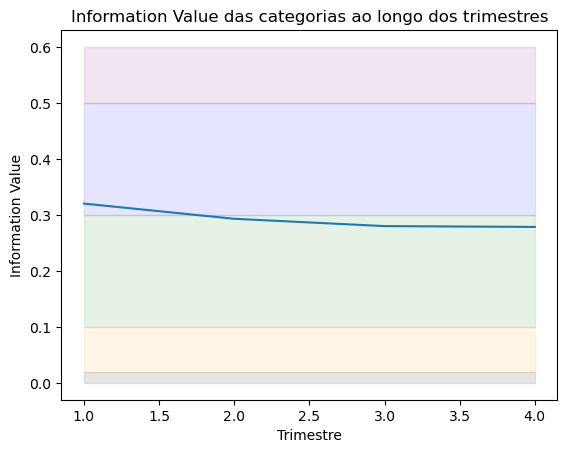

In [27]:
def plot_iv(IV):
    fig, ax = plt.subplots()
    x = IV.index
    a = [.02]*len(IV.index)
    b = [.1]*len(IV.index)
    c = [.3]*len(IV.index)
    d = [.5]*len(IV.index)
    e = [.6]*len(IV.index)

    ax.fill_between(IV.index, a, color='grey', alpha=.2)
    ax.fill_between(IV.index, a, b, color='orange', alpha=.1)
    ax.fill_between(IV.index, b, c, color='green', alpha=.1)
    ax.fill_between(IV.index, c, d, color='blue', alpha=.1)
    ax.fill_between(IV.index, d, e, color='purple', alpha=.1)
    ax.plot(IV)

    ax.set_title("Information Value das categorias ao longo dos trimestres")
    ax.set_ylabel("Information Value")
    ax.set_xlabel("Trimestre")
    
plot_iv(iv_categoria)

## Conclua

- Quais categorias parece ter maior proporção de notas com retornos maiores que zero?
- Essas diferenças são estáveis no tempo?

Dicas:<br>
- Considere que a quantidade de notas vem aumentando
- Considere que há períodos bem atípicos no histórico
- Considere que a partir de janeiro de 2020 o público é mais parecido com o público atual (2022), seja por pandemia, seja por crescimento do público, e considere os dados dessa data em diante na sua conclusão.

A partir de 2020, as categorias Alimentos e Restaurantes se destacam por apresentarem as maiores e mais consistentes proporções de notas fiscais com retorno positivo, evidenciando seu potencial preditivo para modelos de crédito. Enquanto Alimentos e Auto Posto demonstram estabilidade temporal, Restaurantes apresenta maior volatilidade ao longo dos períodos analisados. A categoria Farmácia, por sua vez, revela um crescimento constante no potencial de retorno. De modo geral, o conjunto de categorias analisadas possui um poder preditivo médio, indicando que, apesar de algumas variações, essas variáveis são relevantes para discriminar o comportamento de retorno nos dados atuais.
